# 7. 对抗性防御算法之对抗性训练（2）

## 7.0 上节内容回顾与本节主要内容介绍

在上节中，我们了解了对抗性训练算法，并实现了FGSM对抗性训练。在本节中，我们将实现使用PGD进行对抗性训练。

本实验的主要内容为采用Python、PyTorch等技术，实现基于PGD攻击的对抗性训练，并进行鲁棒性测试。

## 7.1 导入相关模块

In [1]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import importlib.util
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import logging

from tabulate import tabulate
import test; test_fn = test.test
from loss import LabelSmoothingCrossEntropyLoss, CWLoss
from pgd import LinfPGD
from utils import load_mnist_test
from models import LeNet5, FCNet


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 7.2 基于PGD攻击进行对抗性训练

在上一节中，我们实现了FGSM对抗性训练。尽管FGSM攻击是最简单的攻击算法之一，但是基于FGSM的对抗性训练的代码仍然比标准训练复杂很多。

在本节中，我们尝试用一个类来实现对抗性训练，这样做的好处是能够在几乎不修改训练过程代码的前提下实现对抗性训练。

In [2]:
class AdversarialTraining(nn.Module):
    """
        AdversarialTraining类实现了基于PGD攻击框架的对抗性训练，并且能够适配大部分神经网络对象，
    比如LeNet5和FCNet。这个类的父类仍然是nn.Module，这使得AdversarialTraining实例能够像LeNet5和
    FCNet等类的实例那样完成训练、测试以及模型的保存与加载。不同的是， AdversarialTraining实例具
    有两种模式，由is_at控制。
        当is_at为False时， AdversarialTraining实例的表现几乎与直接使用LeNet5和FCNet等类的实例完
    全一致，唯一的差别是AdversarialTraining实例的参数state_dict的键有'model.'前缀，因此如果直接
    保存了AdversarialTraining实例的state_dict，在模型加载时也需要用AdversarialTraining实例加载。
    为了保持和其它实验所保存模型的统一，本实验在保存模型时，保存了AdversarialTraining实例的变量
    model的state_dict，在加载时，如果希望继续使用AdversarialTraining实例，可以先创建model，然后
    加载state_dict，最后用model构造AdversarialTraining实例。
        当is_at为True时，AdversarialTraining实例在forward中包含了产生对抗性训练样本的过程，并且
    自动控制梯度计算和更新，不需要修改训练的代码即可实现对抗性训练。
    """
    def __init__(self, model, eps=0.1, step=5, step_size=0.025, random_start=True, criterion=F.cross_entropy, is_at=False):
        super(AdversarialTraining, self).__init__()
        self.model = model
        self.adversary = LinfPGD(self.model, 
                                 eps=eps, 
                                 step_size=step_size, 
                                 step=step, 
                                 random_start=random_start, 
                                 criterion=criterion)
        self.is_at = is_at
    
    def forward(self, x, y=None):
        if self.is_at:
            # 记录模型状态
            training = self.model.training

            assert y is not None
            
            # 在创造对抗性样本时，模型开启测试模式
            self.model.eval()
            x_adv = self.adversary((x, y))
            
            # 如果在训练过程中，需要将模型转化为训练模式；否则保持测试模式
            if training:
                self.model.train()
            return self.model(x_adv)
        else:
            return self.model(x)

In [3]:
# 超参数
EPOCH = 50              # 训练总epoch数
BATCH_SIZE = 256        # 训练batch size大小
LR = 0.001              # 初始学习率
DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）

EPS = 0.1               # 攻击限制
STEP_SIZE = 0.025       # 攻击步长
STEP = 5                # 攻击步数
RANDOM_START = True     # 攻击是否随机初始化

if not(os.path.exists('./data/')) or not os.listdir('./data/'):
    DOWNLOAD_MNIST = True

In [4]:
# 导入数据，定义数据接口
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [5]:
# 定义网络结构并统计模型参数
from models import LeNet5

cnn = LeNet5().to(device)
print(cnn)  # 网络结构（这也是PyTorch的一大优点，即可用print很方便的得到网络的直观形式）

# 使用Adam Optimizer
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

# 配置损失函数
loss_function = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print('模型参数大小为：', num_params)

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


In [6]:
cnn_at = AdversarialTraining(cnn, eps=EPS, step=STEP, step_size=STEP_SIZE, random_start=RANDOM_START, is_at=True)

In [7]:
"""
    在cnn_at.is_at = True的前提下，cnn_at将先对输入的任何样本进行攻击再进行测试。
因此，此处的train_accs, train_losses, test_accs, test_losses与以往实验中的含义不
同，它们均为经过相应的攻击（此处为PGD5）后的指标。
"""
train_accs = []
train_losses = []
test_accs = []
test_losses = []

for epoch in range(EPOCH):
    # 训练
    cnn_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn_at(inputs, labels)

        loss = loss_function(outputs, labels)  # 对抗性训练需要传入标签用于流程中的攻击
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.max(dim=1).indices        
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.data.item() * n
        
    train_accs.append(train_correct / train_total)
    train_losses.append(train_loss / train_total)
    logger.info(f'training epoch: {epoch}, loss: {train_loss / train_total:.2f}, acc: {100 * train_correct / train_total:.2f}%')

    # 测试
    cnn_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_at(inputs, labels)
            loss = loss_function(outputs, labels)
            

            pred = outputs.max(dim=1).indices  
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.data.item() * n

    test_accs.append(test_correct / test_total)
    test_losses.append(test_loss / test_total)

    logger.info(f'    test epoch: {epoch}, loss: {test_loss / test_total:.2f}, acc: {100 * test_correct / test_total:.2f}%')

 25056 20260207 13:17:05 training epoch: 0, loss: 0.86, acc: 70.20%
 25056 20260207 13:17:09     test epoch: 0, loss: 0.41, acc: 86.14%
 25056 20260207 13:17:35 training epoch: 1, loss: 0.35, acc: 88.39%
 25056 20260207 13:17:40     test epoch: 1, loss: 0.29, acc: 90.20%
 25056 20260207 13:18:06 training epoch: 2, loss: 0.28, acc: 90.95%
 25056 20260207 13:18:10     test epoch: 2, loss: 0.24, acc: 92.14%
 25056 20260207 13:18:37 training epoch: 3, loss: 0.24, acc: 92.25%
 25056 20260207 13:18:41     test epoch: 3, loss: 0.21, acc: 92.73%
 25056 20260207 13:19:08 training epoch: 4, loss: 0.21, acc: 92.99%
 25056 20260207 13:19:12     test epoch: 4, loss: 0.20, acc: 93.32%
 25056 20260207 13:19:39 training epoch: 5, loss: 0.19, acc: 93.44%
 25056 20260207 13:19:43     test epoch: 5, loss: 0.18, acc: 93.76%
 25056 20260207 13:20:10 training epoch: 6, loss: 0.18, acc: 94.09%
 25056 20260207 13:20:14     test epoch: 6, loss: 0.16, acc: 94.51%
 25056 20260207 13:20:42 training epoch: 7, loss

可以看到，通过AdversarialTraining这个类，我们可以很容易地复用原来的标准训练代码，使整个训练流程代码保持简洁。

需要注意的是，此处所打印的训练过程中的训练准确率和测试准确率，均为对抗性训练所使用的攻击算法攻击之后的准确率。

In [8]:
# 保存模型，此处保存cnn的state_dict，而非cnn_at，后续加载时需要使用LeNet5对象
# 如果保存cnn_at.state_dict()则需用AdversarialTraining对象加载
state = {
    'net': cnn.state_dict(),
    'num_epoch': epoch,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
}

result_path = f'./save_model/' + str(EPOCH) + 'epoch'
if not os.path.isdir(result_path):
    os.makedirs(result_path)
torch.save(state, result_path + f'/mnist_lenet5_PGD_{EPS}_{STEP}_AT.pth')

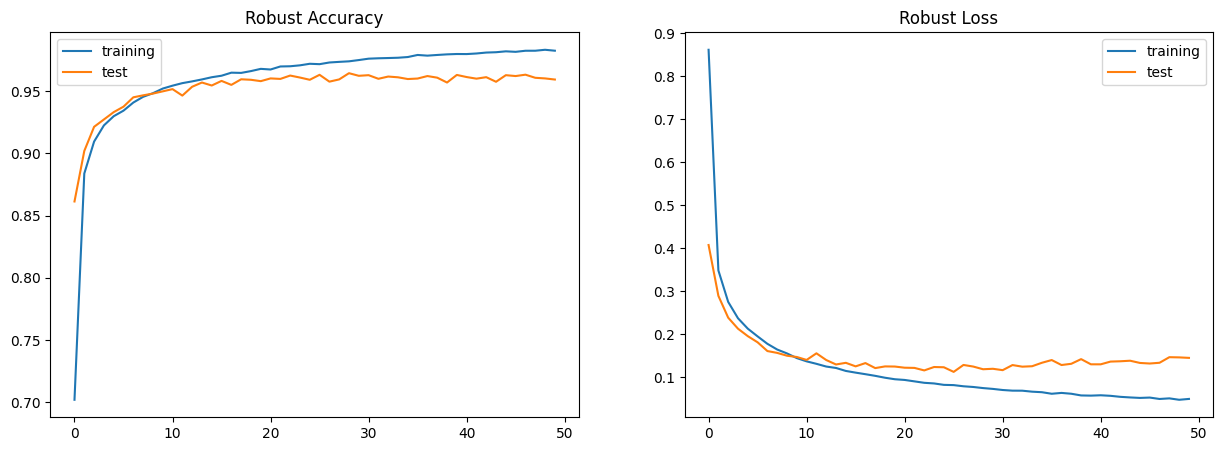

In [9]:
plt.figure(figsize=(15, 5))

idx = [_ for _ in range(EPOCH)]
plt.subplot(1, 2, 1)
plt.plot(idx, train_accs, label='training')
plt.plot(idx, test_accs, label='test')
plt.legend()
plt.title('Robust Accuracy')

plt.subplot(1, 2, 2)
plt.plot(idx, train_losses, label='training')
plt.plot(idx, test_losses, label='test')
plt.legend()
plt.title('Robust Loss')

plt.show()

## 7.3 鲁棒性测试

### 7.3.0 白盒攻击测试

In [11]:
# 定义攻击参数
FGSM_kwargs = dict(net=cnn, eps=0.1, step=1, step_size=0.1, random_start=False)
PGD_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 加载样本
imgs, lbls = load_mnist_test()

# 执行测试
cln_acc, _ = test_fn(cnn, imgs, lbls, bs=250, mode='clean')                         # 干净样本
fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')  # FGSM
pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')    # PGD
cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')      # CW

logger.info(f'PGD_{EPS}_{STEP} AT - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}')

 25056 20260207 14:46:39 PGD_0.1_5 AT - Clean: 99.30, FGSM: 96.10, PGD: 94.93, CW: 95.04


可以看到，对抗性训练模型取得了非常好的白盒测试结果。

### 7.3.1 迁移攻击测试

使用标准模型作为替代模型进行迁移攻击

In [13]:
# 模型加载
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义攻击参数
FGSM_kwargs = dict(net=std_lenet, eps=0.1, step=1, step_size=0.1, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=0.1, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 执行测试
trans_fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')  # FGSM
trans_pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')    # PGD
trans_cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')      # CW

logger.info(f'Transfer Attack - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}')

 25056 20260207 14:47:04 Transfer Attack - FGSM: 98.33, PGD: 98.34, CW: 99.10


结果表示，PGD5对抗性训练模型能够抵抗迁移攻击。

### 7.3.2 AutoAttack测试

In [14]:
from autoattack import AutoAttack

adversary = AutoAttack(cnn, eps=0.1)

x_adv = adversary.run_standard_evaluation(imgs, lbls)

setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 99.30%
apgd-ce - 1/40 - 5 out of 250 successfully perturbed
apgd-ce - 2/40 - 15 out of 250 successfully perturbed
apgd-ce - 3/40 - 10 out of 250 successfully perturbed
apgd-ce - 4/40 - 11 out of 250 successfully perturbed
apgd-ce - 5/40 - 14 out of 250 successfully perturbed
apgd-ce - 6/40 - 13 out of 250 successfully perturbed
apgd-ce - 7/40 - 12 out of 250 successfully perturbed
apgd-ce - 8/40 - 10 out of 250 successfully perturbed
apgd-ce - 9/40 - 9 out of 250 successfully perturbed
apgd-ce - 10/40 - 9 out of 250 successfully perturbed
apgd-ce - 11/40 - 7 out of 250 successfully perturbed
apgd-ce - 12/40 - 9 out of 250 successfully perturbed
apgd-ce - 13/40 - 6 out of 250 successfully perturbed
apgd-ce - 14/40 - 9 out of 250 successfully perturbed
apgd-ce - 15/40 - 15 out of 250 successfully perturbed
apgd-ce - 16/40 - 22 out of 250 successfully perturbed
apgd-c

回顾之前的防御模型的AutoAttack准确率：
- 仅使用干净样本进行训练的标准模型 - 17.40
- 使用label smoothing进行训练的模型 - 8.47
- 使用FGSM进行对抗性训练的模型 - 36.48
- 本节，使用PGD5进行对抗性训练的模型 - 95.02

在目前所有的模型里，PGD5对抗性训练模型取得了最好的AutoAttack测试结果。第二名为FGSM对抗性训练模型，其结果为36.48%，与PGD5对抗性训练模型相差巨大。